# Машинное обучение, DS-поток
## Задание ML.9

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания будут сдавать устный зачет.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, **не исправляйте и не удаляйте условия!** Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.

**Правила оформления теоретических задач:**

* Решения необходимо прислать в виде $\LaTeX$ в markdown-ячейках.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.

**Баллы за задание:**

* Задача 1 &mdash;  190 баллов.


In [ ]:
# Bot check

# HW_ID: ds_ml9
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [67]:
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from shutil import copyfile
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

import torch
from torch import nn
import torchvision
from torchvision import transforms

import wandb
from pytorch_lightning import LightningModule, Trainer
from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import Callback, ModelCheckpoint

from sklearn.model_selection import train_test_split
from torchmetrics import F1Score
device = f"cuda" if torch.cuda.is_available() else "cpu"
from torchvision.models import resnet50
from torchmetrics.functional import accuracy

In [6]:
sns.set(style='darkgrid', palette='Set2')
wandb.login()

wandb: Currently logged in as: nekirill2015 (nekirill2015-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

### Задача 2
#### Классификация бабочек
Вы — молодой специалист по анализу данных — в составе экспедиции выехали в тропические леса Амазонии. Ваша команда неделями пробиралась сквозь непросветные джунгли, документируя редчайшие виды бабочек. Каждый день тысячи фотографий, каждая бабочка уникальна.

Однако не всё пошло гладко. На седьмой день экспедиции случилось непредвиденное: несколько из членов вашей команды подскользнулись на влажном камне, упали в реку, и все их записи с пометками, какой их фотографии соответствует какой вид бабочки, уплыли...

Финансирование экспедиции зависит от успешного предоставления результатов по классификации всех сделанных фотографий. Времени на ручную повторную классификацию нет. Остальные члены экспедиции разбросаны по другим экспедициям в труднодоступных местах без связи.

**Ваша миссия:** разработать ML-модель, которая сможет автоматически классифицировать все фотографии бабочек. Это не просто учебное задание — от вас зависит судьба экспедиции, научная репутация команды и, возможно, открытие новых видов!

P.S. Глава экспедиции обещал назвать новооткрытый вид бабочки в честь победителя соревнования. Представляете: *Papilio [ваше_имя]*. Звучит неплохо, правда?

#### 📂 Данные
В соревновании вам предоставлены:  
* `train` — папка с изображениями из обучающей выборки;  
* `test` — папка с тестовыми изображеними;  
* `Training_set.csv` — таблица соответствия изображений из обучающей выборки с классами бабочек;
* `Testing_set.csv` — таблица с номерами изображений их тестовой выборки;
* `sample_submission.csv` — пример для вашего submission.

#### 📊 Оценка результатов
**Основной метрикой** оценки является **Accuracy** — доля правильно классифицированных изображений:

$$\text{Accuracy} = \frac{\text{Количество правильных предсказаний}}{\text{Общее количество предсказаний}}$$

Ссылка: https://www.kaggle.com/competitions/ds-3-2025-ml-9/

Инвайт: https://www.kaggle.com/t/8b869415a50b4305a383ced0d4f0b729

**📋 Правила**

* В Kaggle в данное тренировочное соревнование можно отправлять не более 10 решений в день (11-ю система не позволит).
* Решения индивидуальные.
* Качество считается по метрике Accuracy.
* До окончания соревнования доступны значения качества, посчитанные только на случайных 40% тестовых данных. Значения отображаются в Public Leaderboard.
* После окончания соревнования становится доступным Private Leaderboard, в котором значения качества посчитанны на оставшихся 60% объектов.
* Для включения в Private Leaderboard можно выбрать две посылки.
* В Leaderboard должны отображаться ваши **реальные имя и фамилия**. В противном случае решение может быть не зачтено.
* Все файлы, которые вы отправляете в соревнование, видны организаторам соревнования. Файлы должны иметь понятное имя, при отправке файла в систему необходимо написать краткое описание решения. **Это будет проверяться.**
* В решении, отправляемом боту, должно быть отображено, результаты каких моделей вы отправляете в соревнование.
* Не забывайте сделать пояснения к своему решению. **Решение может быть не зачтено, если в нем недостаточно пояснений**, даже если удалось попасть в топ-3.
* Пользоваться можно любыми пройденными в наших курсах моделями.
* Нельзя пользоваться любыми методами и моделями, которые мы не проходили, и которых не было в ранее в иных курсах, которые обязательны для всех.
* Код студентов, занявших первые 3 места, будет запускаться. Также выборочно может запускаться код и остальных студентов.

**💡 Некоторые советы:**
- Разделите обучающие данные на train и val, так чтобы сохранилось процентное соотноеение классов.
- Все свои эксперементы оценивайте на val, но итовую модель перед submission можно обуить на всех данных.
- Возьмите предобученную модель, полезно будет рассмотреть `ResNet50`, `EfficientNet-B0`, `ConvNeXt`.
- Попробуйте разные стратегии fine-tuning: обучите только классификационный слой, затем всю модель с маленькой скоростью обучения. Можете попробовать проемежуточный вариант с частичной разморозкой.
- Для бабочек важен цвет, поэтому подбирайте аугментации с умом.
- Попробуйте разные лоссы, learning rate, возможно, потребуется использование шедулеров.

**⏰Сроки сдачи**

* **Дедлайн в Kaggle** совпадает с дедлайном по заданию (05.11 16:00). Дедлайн строгий, Kaggle не позволит сдать даже на секунду позже.
* Также **до дедлайна необходимо сдать в бот** существующий вариант решения, возможно, без пояснений.
* **До конца следующих суток  (06.11 23:59)** необходимо дооформить решение, соответствующее наилучшему варианту по Private Leaderboard и сдать в бот по отдельной кнопке. **Решение может быть не зачтено, если в нем недостаточно пояснений**, даже если удалось попасть в топ-3.
* В случае, если вы до основного дедлайна сдаете оформленное решение, его нужно сдать по двум кнопкам сразу &mdash; соответствующей основной сдаче, и отдельной для оформленного решения.

**💯 Баллы**

...

In [73]:
# Прочитаем данные
zip_path = 'ds-3-2025-ml-9.zip'
zip_path_bash = str(zip_path).replace(' ', '\ ')
!unzip $zip_path_bash -d .
data_path = Path('./butterfly')

Archive:  ds-3-2025-ml-9.zip
  inflating: ./butterfly/Testing_set.csv  
  inflating: ./butterfly/Training_set.csv  
  inflating: ./butterfly/sample_submission.csv  
  inflating: ./butterfly/test/Image_1.jpg  
  inflating: ./butterfly/test/Image_10.jpg  
  inflating: ./butterfly/test/Image_100.jpg  
  inflating: ./butterfly/test/Image_1000.jpg  
  inflating: ./butterfly/test/Image_1001.jpg  
  inflating: ./butterfly/test/Image_1002.jpg  
  inflating: ./butterfly/test/Image_1003.jpg  
  inflating: ./butterfly/test/Image_1004.jpg  
  inflating: ./butterfly/test/Image_1005.jpg  
  inflating: ./butterfly/test/Image_1006.jpg  
  inflating: ./butterfly/test/Image_1007.jpg  
  inflating: ./butterfly/test/Image_1008.jpg  
  inflating: ./butterfly/test/Image_1009.jpg  
  inflating: ./butterfly/test/Image_101.jpg  
  inflating: ./butterfly/test/Image_1010.jpg  
  inflating: ./butterfly/test/Image_1011.jpg  
  inflating: ./butterfly/test/Image_1012.jpg  
  inflating: ./butterfly/test/Image_1013.jp

In [47]:
train_set = pd.read_csv(data_path/'Training_set.csv')
test_set = pd.read_csv(data_path/'Testing_set.csv')

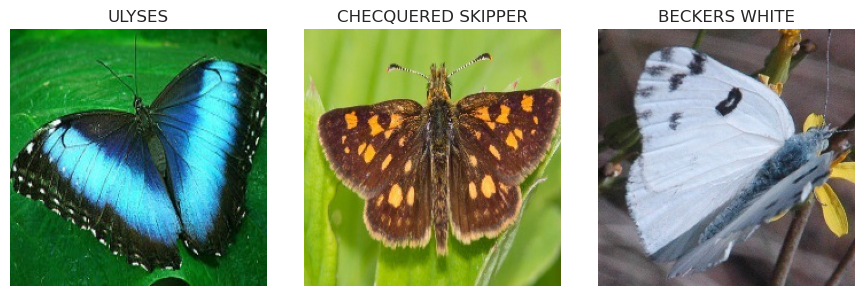

In [48]:
# Посмотрим на несколько картинок
images_paths = [
    data_path/'train'/'Image_1008.jpg',
    data_path/'train'/'Image_1618.jpg',
    data_path/'train'/'Image_1899.jpg'
]
nums = [1007, 1617, 1898]
plt.figure(figsize=(9, 3))
for i, image_path in enumerate(images_paths):
    plt.subplot(1, 3, i + 1)
    image = plt.imread(image_path)
    plt.imshow(image)
    plt.title(*train_set[train_set['filename'] == nums[i]]['label'].values)
    plt.axis("off")
plt.tight_layout()

In [49]:
#Выполним предобработку файлов
data_dir = Path(data_path/"train")
csv_path = Path(data_path/'Training_set.csv')
output_dir = Path("data/train_imagefolder")

df = pd.read_csv(csv_path)

df["filename"] = df["filename"].apply(lambda x: f"Image_{int(x) + 1}.jpg")

output_dir.mkdir(parents=True, exist_ok=True)

for _, row in df.iterrows():
    src = data_dir / row["filename"]
    class_name = str(row["label"])
    dst_dir = output_dir / class_name
    dst_dir.mkdir(parents=True, exist_ok=True)
    dst = dst_dir / row["filename"]
    src.rename(dst)

print("Файлы разложены по папкам для ImageFolder.")

Файлы разложены по папкам для ImageFolder.


In [50]:
#Создадим даталоадеры
input_size = 224

train_transform = transforms.Compose([
    transforms.Resize(input_size),
    transforms.CenterCrop(input_size),
    transforms.ColorJitter(0.9, 0.9),  
    transforms.RandomAffine(15),           
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize(input_size),
    transforms.CenterCrop(input_size),
    transforms.ToTensor(),
])

dataset = torchvision.datasets.ImageFolder("data/train_imagefolder")

labels = [s[1] for s in dataset.samples]
indices = list(range(len(dataset)))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

train_ds = torch.utils.data.Subset(dataset, train_idx)
val_ds   = torch.utils.data.Subset(dataset, val_idx)

train_ds.dataset.transform = train_transform
val_ds.dataset.transform   = val_transform

batch_size = 32
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = torch.utils.data.DataLoader(val_ds, batch_size=batch_size, shuffle=False)

In [51]:
#Создадим класс модели, унаследуем от LightningModule
class FineTunedResNet(LightningModule):
    def __init__(self, n_classes, to_freeze = -1, lr = 1e-4):
        '''Инициализация модели
        * to_freeze -- сколько слоев хотим заморозить.
        * n_classes -- кол-во классов'''

        super().__init__()

        self.n_classes = n_classes
        self.criterion = nn.CrossEntropyLoss()
        self.lr = lr
        self.save_hyperparameters()

        backbone = resnet50(weights='ResNet50_Weights.DEFAULT')
        num_filters = backbone.fc.in_features
        layers = list(backbone.children())[:-1]

        n_layers = len(layers) - 1
        if to_freeze > n_layers:
            to_freeze = n_layers
        elif to_freeze < 0:
            to_freeze = 0

        self.feature_extractor = nn.Sequential(*layers)
        for block in self.feature_extractor[:to_freeze]:
          for param in block.parameters():
              param.requires_grad = False

        self.test_preds = []
        self.test_targets = []

        # добавляем 2 FC слоя после выходов предобученной неросети
        self.classifier = nn.Sequential()
        self.classifier.add_module('relu_1', nn.ReLU())
        self.classifier.add_module('fc_1', nn.Linear(num_filters, 512))
        self.classifier.add_module('relu_2', nn.ReLU())
        self.classifier.add_module('fc_2', nn.Linear(512, self.n_classes))

    def forward(self, x):
        '''Forward pass'''

        representations = self.feature_extractor(x).flatten(1)
        out = self.classifier(representations)
        return out

    def training_step(self, batch, batch_idx):
        '''Возвращает лосс с 1 шага обучения по батчу'''

        _, loss, acc = self.__get_preds_loss_accuracy(batch)

        # Логируем лосс и метрику
        self.log('train_loss', loss)
        self.log('train_accuracy', acc)

        return loss

    def validation_step(self, batch, batch_idx):
        '''Используется для логирования метрик'''

        preds, loss, acc = self.__get_preds_loss_accuracy(batch)

        # Логируем лосс и метрику
        self.log('val_loss', loss)
        self.log('val_accuracy', acc)

        # Возвращаем предсказания, чтобы использовать их в callback
        return preds

    def configure_optimizers(self):
        '''Определяет оптимизатор модели'''

        return torch.optim.AdamW(self.parameters(), lr=self.lr)

    def __get_preds_loss_accuracy(self, batch):
        '''Вспомогательная функция для шага обучения / валидации'''

        x, y = batch
        logits = self(x)
        preds = torch.argmax(logits, dim=1)
        loss = self.criterion(logits, y)
        acc = accuracy(preds, y, 'multiclass', num_classes=self.n_classes)
        return preds, loss, acc

    def test_step(self, batch, batch_idx):
        preds, _, _ = self.__get_preds_loss_accuracy(batch)
        _, y = batch
        self.test_preds.append(preds.detach())
        self.test_targets.append(y.detach())

In [61]:
#Создадим логгер
class LogPredictionsCallback(Callback):
    def __init__(self, n_classes: int):
        super().__init__()
        self.n_classes = n_classes
        self.train_f1 = F1Score(task='multiclass', num_classes=n_classes, average='macro').to(device)
        self.val_f1   = F1Score(task='multiclass', num_classes=n_classes, average='macro').to(device)

    # Батч на тренировке
    def on_train_batch_end(self, trainer, pl_module, outputs, batch, batch_idx, unused=0):
        x, y = batch
        logits = pl_module(x)
        preds = torch.argmax(logits, dim=1)
        self.train_f1.update(preds, y)

    # Батч на валидации
    def on_validation_batch_end(self, trainer, pl_module, outputs, batch, batch_idx, unused=0):
        x, y = batch
        logits = pl_module(x)
        preds = torch.argmax(logits, dim=1)
        self.val_f1.update(preds, y)

    # Конец эпохи тренировки
    def on_train_epoch_end(self, trainer, pl_module):
        f1 = self.train_f1.compute()
        pl_module.log("train_f1", f1, on_epoch=True, prog_bar=True)
        self.train_f1.reset()

    # Конец эпохи валидации
    def on_validation_epoch_end(self, trainer, pl_module):
        f1 = self.val_f1.compute()
        pl_module.log("val_f1", f1, on_epoch=True, prog_bar=True)
        self.val_f1.reset()

n_classes = len(dataset.classes)
log_predictions_callback = LogPredictionsCallback(n_classes)

In [68]:
#Посмотрим на метрику по resnet50 с различными глубинами заморозки
model = FineTunedResNet(n_classes=n_classes, to_freeze=to_freeze)

checkpoint_callback = ModelCheckpoint(
    monitor='val_accuracy',
    mode='max',
    dirpath=f'./checkpoints/to_freeze={to_freeze}',
    filename='epoch={epoch}-val_acc={val_accuracy:.3f}'
)

wandb_logger = WandbLogger(
    project='Butterflies',
    log_model='all',
    name=f'to_freeze={to_freeze}',
)

trainer = Trainer(
    logger=wandb_logger,
    callbacks=[log_predictions_callback, checkpoint_callback],
    accelerator='gpu',
    max_epochs=30,
)

torch.cuda.empty_cache()
trainer.fit(model, train_loader, val_loader)

wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name              | Type             | Params | Mode 
---------------------------------------------------------------
0 | criterion         | CrossEntropyLoss | 0      | train
1 | feature_extractor | Sequential       | 23.5 M | train
2 | classifier        | Sequential       | 1.1 M  | train
---------------------------------------------------------------
24.6 M    Trainable params
0         Non-trainable params
24.6 M    Total params
98.382    Total estimated model params size (MB)
156       Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                        | 0/? [00:00<?, ?it/s]

/home/kirill/miniconda3/envs/DScource/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |                                               | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

...

Training: |                                               | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

AuthenticationError: An error occurred while verifying the API key.

In [69]:
#Загрузим лучшую модель

run = wandb.init(project="Butterflies")  

artifact = run.use_artifact('nekirill2015-/Butterflies/model-tsn1e7pr:v7', type='model')
artifact_dir = artifact.download()
print("Артефакт загружен в:", artifact_dir)

epoch,▁▁▁▁▅▅▅▅███
train_accuracy,▁▄▇██▇
train_f1,▁█
train_loss,█▄▂▁▁▁
trainer/global_step,▁▂▃▃▃▅▅▅▆▇█
val_accuracy,▁▇█
val_f1,▁▇█
val_loss,█▂▁
epoch,2
train_accuracy,0.90625
train_f1,0.92061


wandb: Downloading large artifact 'model-tsn1e7pr:v7', 281.92MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.5 (538.5MB/s)


Артефакт загружен в: /home/kirill/Education/Python/DScource/ML9/artifacts/model-tsn1e7pr:v7


In [70]:
ckpt_path = Path(artifact_dir) / "model.ckpt"

model = FineTunedResNet.load_from_checkpoint(
    ckpt_path,
    n_classes=n_classes,      
)

model.eval()
model.freeze()

In [84]:
import re
from pathlib import Path
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import pandas as pd
import torch.nn as nn

# Параметры (подставьте, если они еще не заданы)
# data_path = Path("/путь/к/вашему/данным")
test_dir = Path(data_path) / "test"
train_imagefolder = Path("data/train_imagefolder")  # чтобы получить class_names
output_csv = Path("submission.csv")

batch_size = 64
num_workers = min(8, (os.cpu_count() or 1))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Получаем имена классов из train ImageFolder (чтобы вернуть строковые имена классов)
from torchvision import datasets
train_ds = datasets.ImageFolder(str(train_imagefolder))
class_names = train_ds.classes  # список строк, индекс соответствует классу

# Трансформации для теста (те же, что и для валидации)
input_size = 224

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(input_size),
    transforms.ToTensor(),
])

# Небольшая функция сортировки "natural" — если имена содержат числа, сортируем по числу
def natural_key(path: Path):
    s = path.stem  # без расширения
    m = re.search(r'(\d+)', s)
    if m:
        return (int(m.group(1)), s)
    return (float('inf'), s)

# Собираем и сортируем пути к изображениям
img_paths = [p for p in test_dir.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png"}]
img_paths = sorted(img_paths, key=natural_key)
print(f"Найдено тестовых изображений: {len(img_paths)}")

# Dataset для теста
class TestImagesDataset(Dataset):
    def __init__(self, img_paths, transform=None):
        self.img_paths = img_paths
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        p = self.img_paths[idx]
        img = Image.open(p).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, p.name

test_dataset = TestImagesDataset(img_paths, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                         num_workers=num_workers, pin_memory=torch.cuda.is_available())

# Убедимся, что модель на device и в eval (вы уже делали, но на всякий случай)
model.to(device)
model.eval()

softmax = nn.Softmax(dim=1)

filenames = []
pred_idx = []
pred_label = []
confidences = []

with torch.no_grad():
    for imgs, names in test_loader:
        imgs = imgs.to(device)
        out = model(imgs)

        # Если модель возвращает tuple/list или dict, попробуем извлечь логи(ты)
        if isinstance(out, (tuple, list)):
            logits = out[0]
        elif isinstance(out, dict):
            # обычно могут быть ключи 'logits' или 'preds'
            if 'logits' in out:
                logits = out['logits']
            elif 'preds' in out:
                logits = out['preds']
            else:
                # если неизвестный формат — попробуем взять первый тензор в dict
                first = next(iter(out.values()))
                logits = first
        else:
            logits = out

        # иногда модель уже возвращает вероятности — проверим диапазон
        if logits.dtype.is_floating_point:
            # гарантируем, что logits имеет форму (B, num_classes)
            if logits.ndim == 1:
                logits = logits.unsqueeze(0)
        else:
            logits = logits.float()

        # если выход уже в диапазоне [0,1] и суммируется по классу — пропустим softmax
        probs = softmax(logits)
        preds = probs.argmax(dim=1).cpu().tolist()

        for name, p in zip(names, preds):
            filenames.append(name)
            pred_idx.append(int(p))
            pred_label.append(class_names[int(p)])

# Формируем DataFrame и сохраняем
df = pd.DataFrame({
    "filename": filenames,
    "label": pred_label,        # строковый лейбл — обычно принимается на Kaggle
})

# Если нужен строго формат "filename,label" (без дополнительных столбцов), используйте:
df[["filename", "label"]].to_csv(output_csv, index=False)
print(f"Сохранён файл: {output_csv} (столбцы: filename,label).")
# Для записи полного CSV с дополнительными колонками:
# df.to_csv("submission_with_confidence.csv", index=False)

Найдено тестовых изображений: 1950
Сохранён файл: submission.csv (столбцы: filename,label).


In [87]:
df['filename'] = range(1950)
df[["filename", "label"]].to_csv(output_csv, index=False)
print(f"Сохранён файл: {output_csv} (столбцы: filename,label).")

Сохранён файл: submission.csv (столбцы: filename,label).


---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока